# Freie Schwingung
## Messen der Daten
Beim Messen der Daten wurde das Drehpendel pro Messung um 90° ausgelenkt und über einen Zeitraum von 20 Sekunden mit einer speziellen Messsoftware aufgezeichnet. DIe Dämpfung des Drehpendes wurde mithilfe zwei Spulen realisiert, somit war die Dämpfung abhängig von der Stromstärke $I$ die durch die Spuelen floss. Die Messungen wurden bei $0.3$ A angefangen und in $0.1$ A Schritten bis $1.2$ A durchgeführt. Da ab $0.5$ A die Dämpfung so stark war, dass die Schwingung nach 10 Skunden nicht mehr vorhaden war, wurde ab $0.5$ A der Zeitraum der Messungen von 20 Sekunden auf 10 verkürzt.

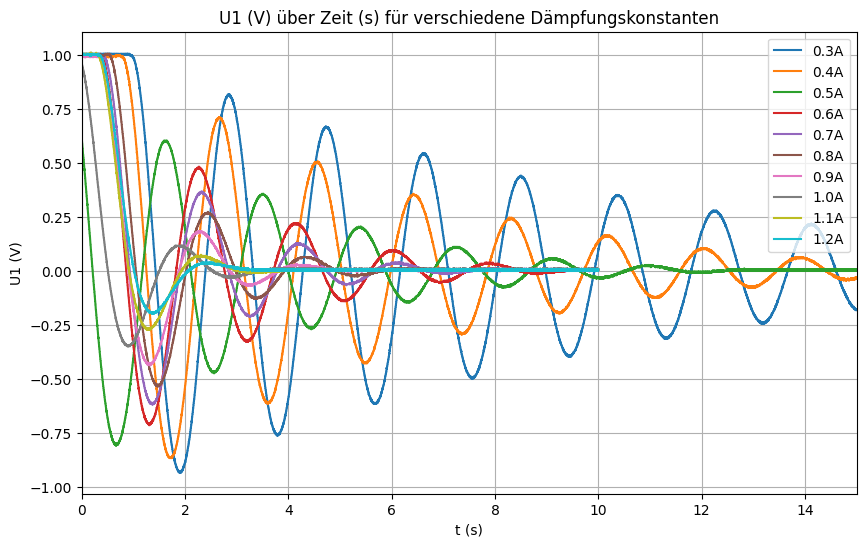

In [5]:
# Plot mit allen Daten von den verschiedenen Dämpfungskonstanten
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os

# Daten einlesen
# Daten aus allen Dateien im Ordner "M10_Aufgabe_1_Daten" einlesen

folder_path = "M10_Aufgabe_1_Daten"
file_names = [f"{i}A_Aufgabe_1_M10.txt" for i in ["0_3", "0_4", "0_5", "0_6", "0_7", "0_8", "0_9", "1_0", "1_1", "1_2"]]

data_frames = []
for file_name in file_names:
    file_path = os.path.join(folder_path, file_name)
    df = pd.read_csv(file_path, sep='\t', names=["t (s)", "U1(V)"], skiprows=1)
    data_frames.append(df)

plt.figure(figsize=(10, 6))
[plt.plot(data_frames[i]["t (s)"], data_frames[i]["U1(V)"], label=f"{(0.3 + 0.1 * i):.1f}A") for i in range(0, len(data_frames))]
plt.xlim(0, 15)
plt.xlabel("t (s)")
plt.ylabel("U1 (V)")
plt.title("U1 (V) über Zeit (s) für verschiedene Dämpfungskonstanten")
plt.grid()
plt.legend()
plt.show()

## Bestimmung der Frequenz $f_d$ und der Abklingkonstante $\delta$
Um die Frequenz $f_d$ und die Abklingkonstante $\delta$ zu bestimmen, wird jede einzelne Schwingung mit einer Fourieranalyse zerlegt. Der Hauptpeak ist die Frequenz $f_d$. Die Abklingkonstante wird über das logarithmische Dekrement bestimmt.
$$\Lambda  = \delta T_d = ln \left( \frac{\phi (t)}{\phi (t + T_d)} \right)$$
Wobei $T_d = 1/ f_d $ die Periodendauer ist.

Wie in der [Abbildung @fig-plot-fft] zu sehen ist, haben alle Plots, ähnliche Werte. Um Messfehler zu minimieren, werden alle Peaks der Plots gemittelt.
$$f_d = \sum_{i}f_{\text{i-te peak}}$$
So kommt eine auf eine gemittelte Aplitude von $f_d = 0.49$ Hz. So folgt eine Kreisfrequenz von $ \omega_d = 2\pi \cdot f_d \approx 3.08$ rad/s.
Das logarithmisches Dekrement wird nach $\delta$ umgestellt, so kommt man auf:
$$\delta = \frac{1}{T_d} ln \left( \frac{\phi (t)}{\phi (t + T_d)} \right)=f_d \cdot ln \left( \frac{\phi (t)}{\phi (t + T_d)} \right)$$

Es gilt $\phi(t) = 1$, da das Pendel immer um 90° ausgelenkt wurde was einem Messwert von 1V entsprach. Bei $\phi(t + T_d)$ wird die Amplitude graphisch ermittelt und das logarithmische Dekrement wird für alle Messungen bestimmt. Die Werte sind in der [Tabelle @fig-tab-plot-fft] zu finden.

**Schätzen Sie den Fehler dieser Größen ab.**

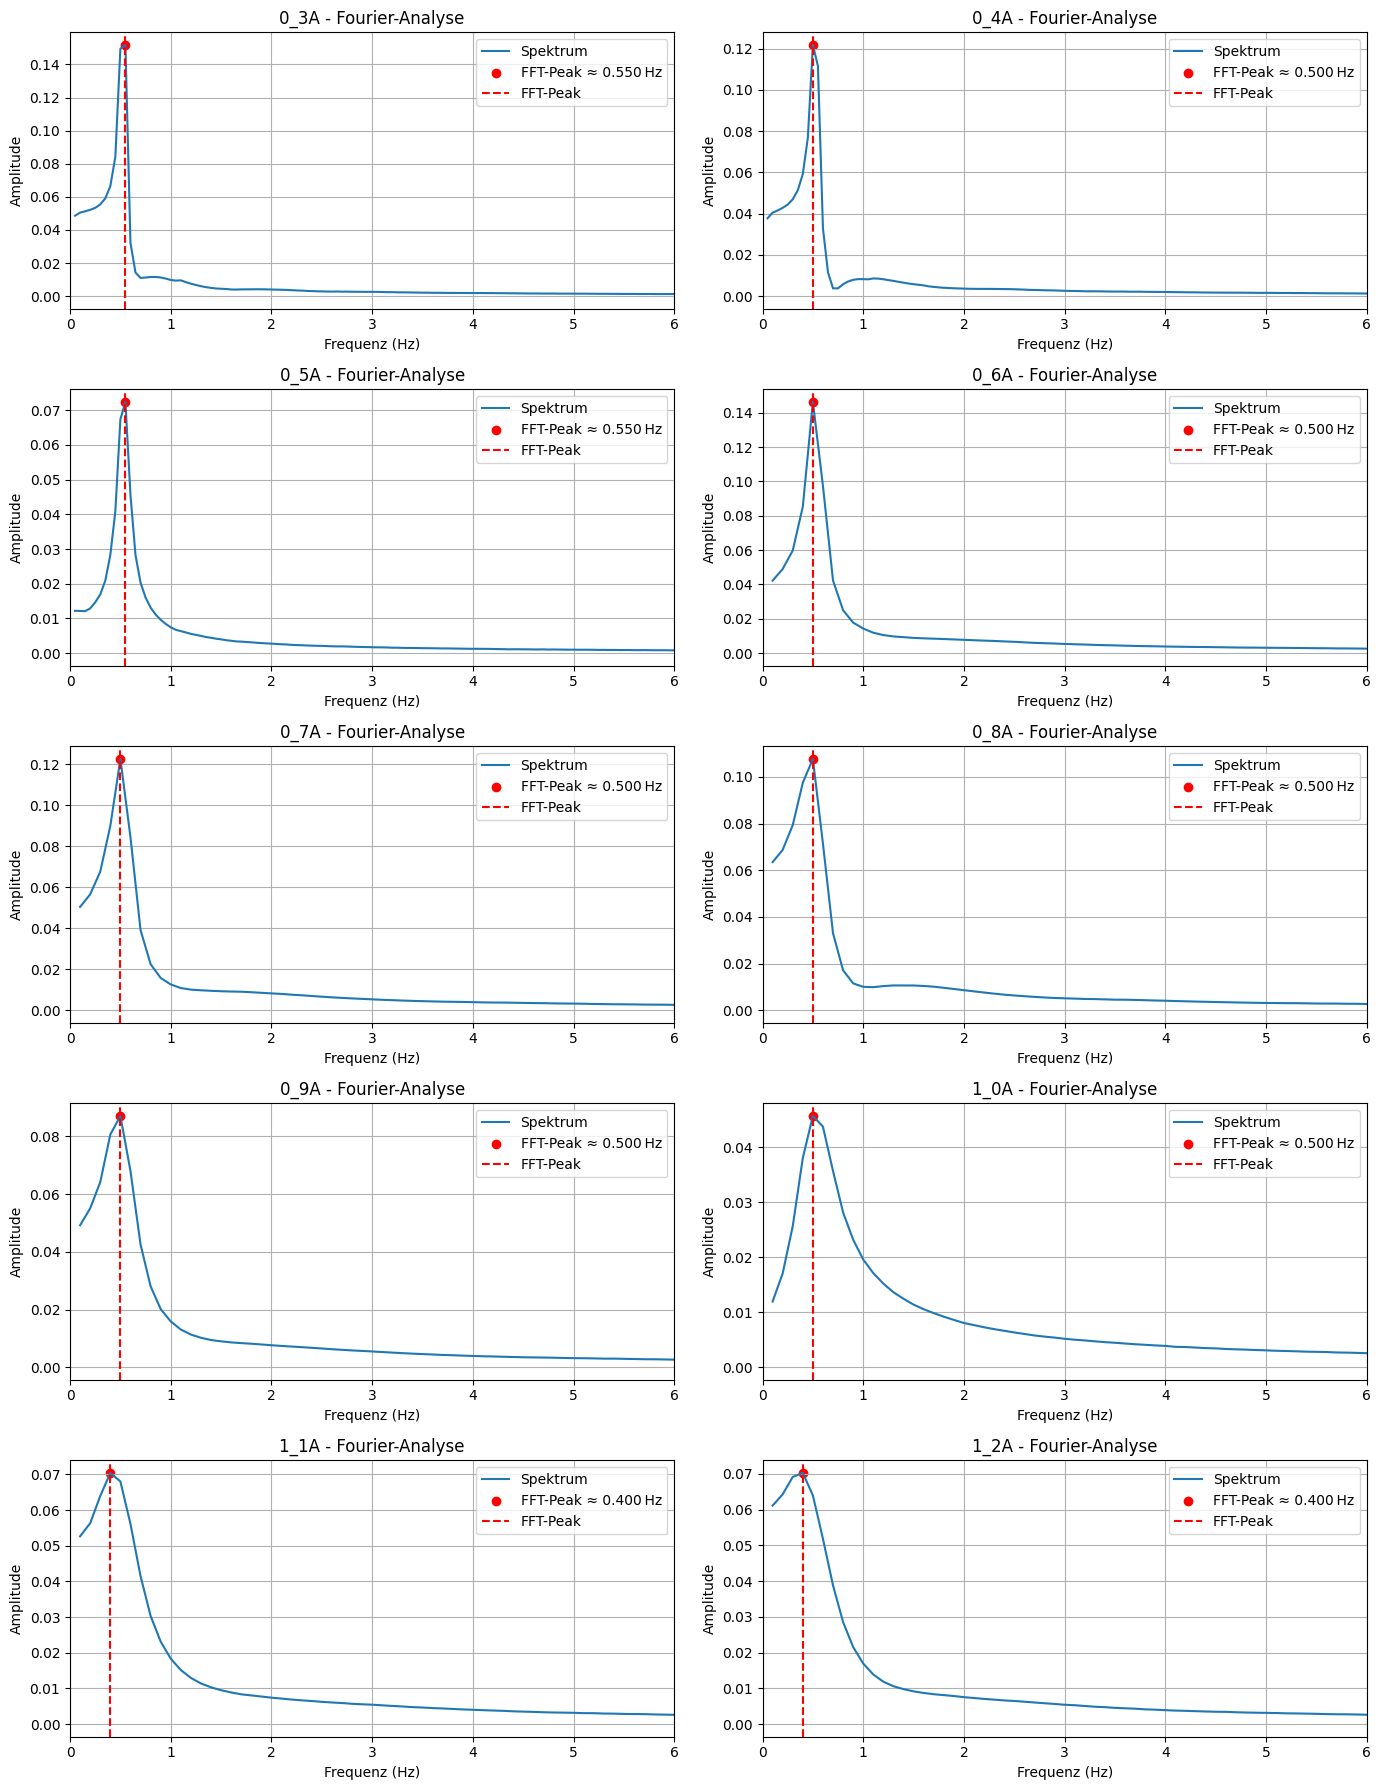

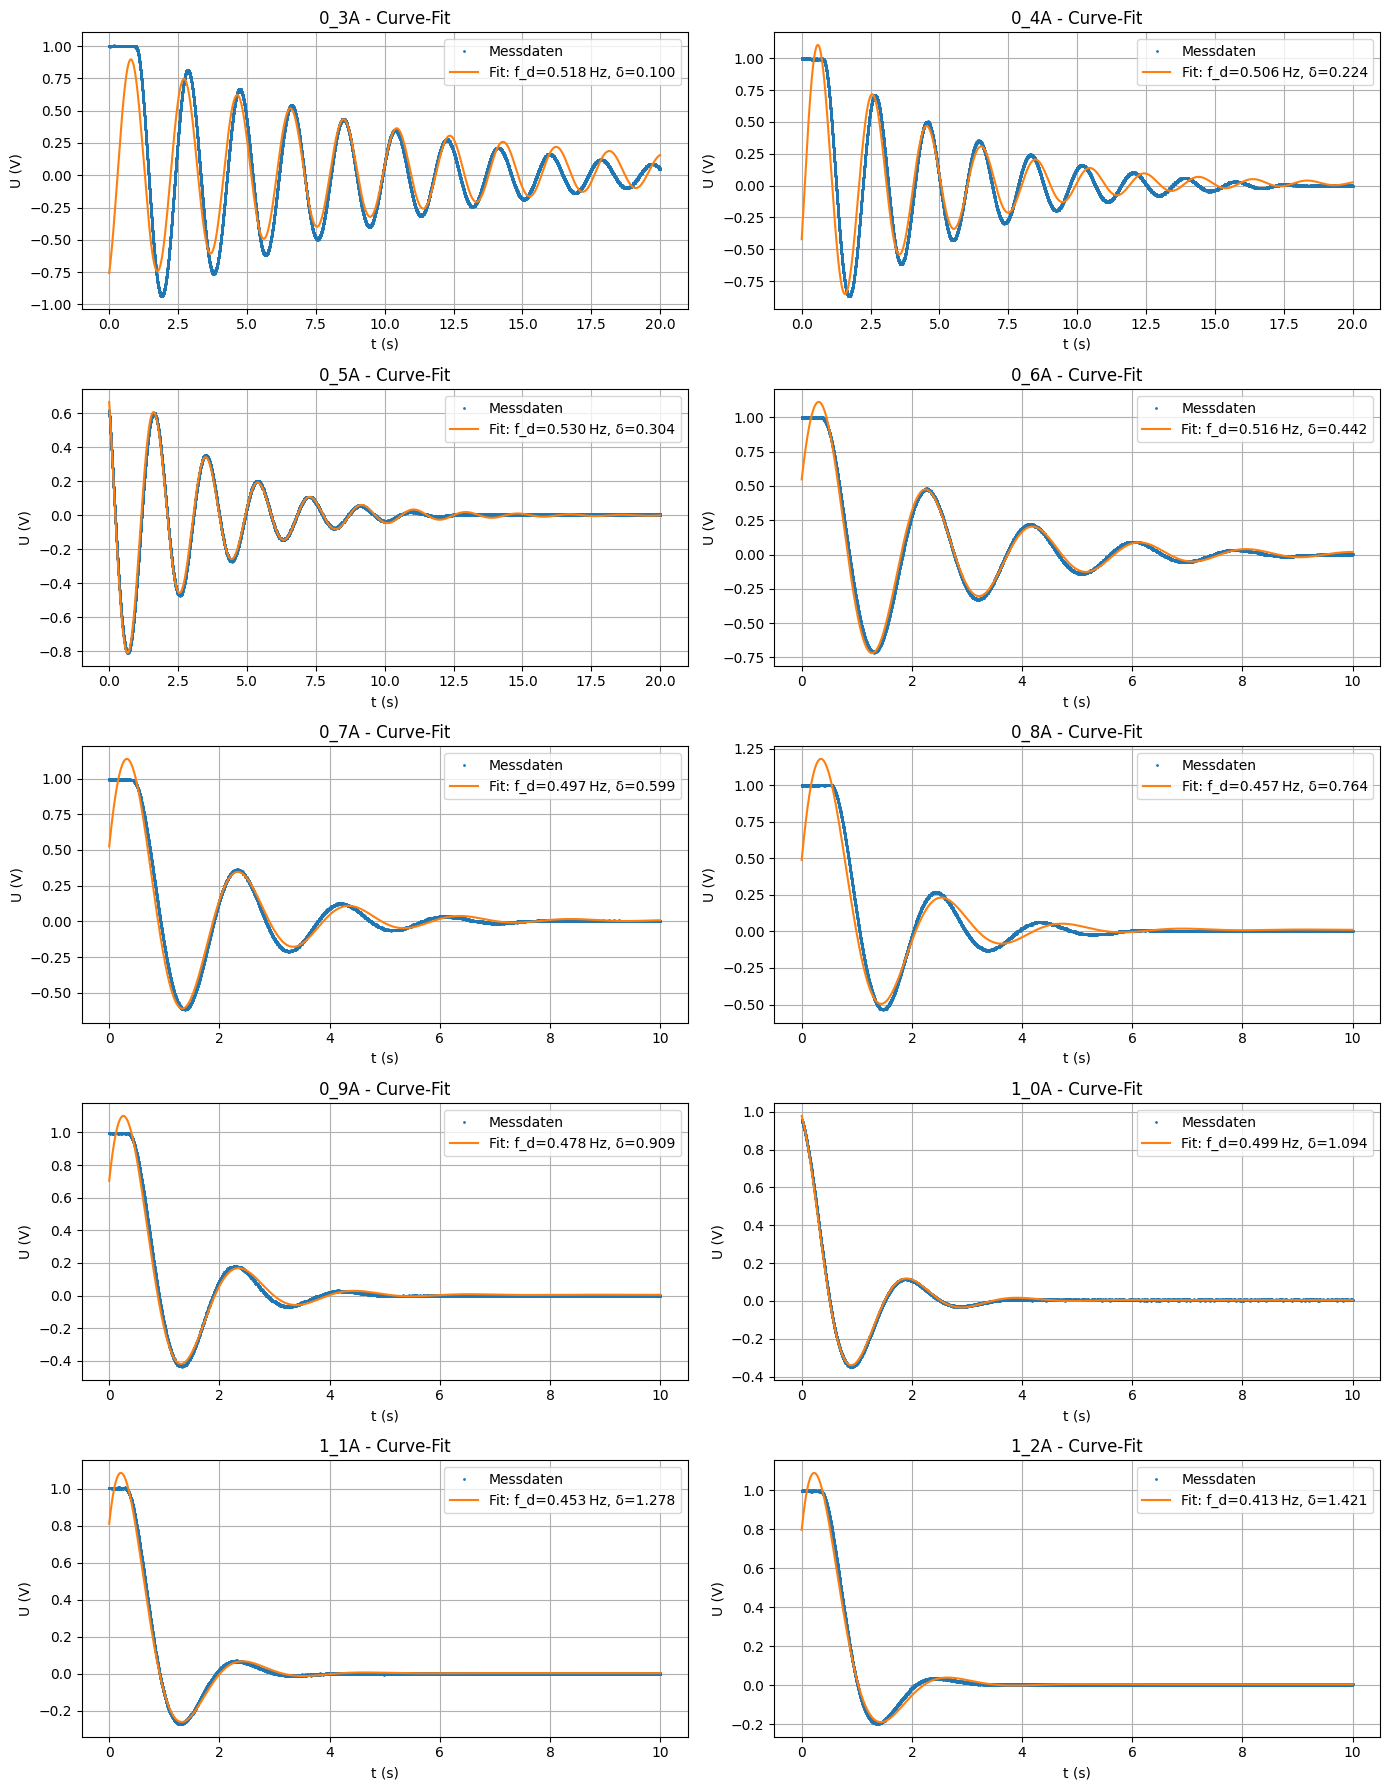

In [6]:
# | label: fig-plot-fft
# | fig-cap: 
# |     - "Fourier-Analyse der Messungen"
# |     - "Curve-Fit an die gedämpfte Sinusfunktion"
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.fft import fft, fftfreq
from scipy.signal import find_peaks
from scipy.optimize import curve_fit
from natsort import natsorted

# ------------------------
# Hilfsfunktionen
# ------------------------

def damped_sinus_function(t, A, delta, omega_d, phase, offset):
    """Gedämpfte Sinusfunktion: A·e^(-delta t)·sin(ω_d t + φ) + offset"""
    return A * np.exp(-delta * t) * np.sin(omega_d * t + phase) + offset

def estimate_omega_fft(t, y):
    """Grobe Abschätzung von ω_d per FFT-Peak"""
    dt = np.mean(np.diff(t))
    n = len(t)
    f = fftfreq(n, d=dt)
    Y = fft(y - np.mean(y))
    # nur positive Frequenzen betrachten
    mask = f > 0
    f_pos = f[mask]
    Ypos = np.abs(Y[mask])
    idx_peak = np.argmax(Ypos)
    freq_peak = f_pos[idx_peak]
    return 2 * np.pi * freq_peak, freq_peak

def fit_damped_sinus(t, y, omega_guess):
    """Curve‑Fit an die gedämpfte Sinusfunktion"""
    A0     = (np.max(y) - np.min(y)) / 2
    delta0 = 0.1         # Startwert Dämpfung
    phi0   = 0.0
    off0   = np.mean(y)
    p0 = [A0, delta0, omega_guess, phi0, off0]
    
    params, cov = curve_fit(
        damped_sinus_function, t, y,
        p0=p0, maxfev=10_000, 
        bounds=([0, 0,      0,   -2*np.pi, -np.inf],
                [np.inf, np.inf, np.inf, 2*np.pi, np.inf])
    )
    return params, cov

# ------------------------
# Daten einlesen
# ------------------------

folder = "M10_Aufgabe_1_Daten"
# Datei-Liste natur­sor­tiert (0_3, 0_4, …, 1_2)
files = natsorted([f for f in os.listdir(folder) if re.match(r'\d+_\dA_Aufgabe_1_M10.txt', f)])

results = []

# ------------------------
# Plot-Vorbereitung
# ------------------------
fig_fft, axes_fft = plt.subplots(5, 2, figsize=(14, 18))
axes_fft = axes_fft.flatten()

fig_fit, axes_fit = plt.subplots(5, 2, figsize=(14, 18))
axes_fit = axes_fit.flatten()

# ------------------------
# Schleife über alle Dateien
# ------------------------
for idx, fn in enumerate(files):
    # Datei einlesen
    path = os.path.join(folder, fn)
    df = pd.read_csv(path, sep='\t', names=["t", "U"], skiprows=1)
    t = df["t"].values
    U = df["U"].values
    
    # 1) FFT-Analyse
    omega_fft, f_fft = estimate_omega_fft(t, U)
    # Berechne Spektrum für Plot
    dt = np.mean(np.diff(t))
    n = len(t)
    f = fftfreq(n, d=dt)
    Y = fft(U - np.mean(U))
    mask = f > 0
    f_pos = f[mask]
    amp = np.abs(Y[mask]) / n
    
    # Peak-Markierung
    peaks_idx, _ = find_peaks(amp, height=np.max(amp)*0.1)
    # nur den höchsten Peak auswählen
    main_peak = peaks_idx[np.argmax(amp[peaks_idx])]
    
    # Plot FFT
    ax = axes_fft[idx]
    ax.plot(f_pos, amp, label="Spektrum")
    ax.scatter(f_pos[main_peak], amp[main_peak], color='red',
               label=f"FFT-Peak ≈ {f_pos[main_peak]:.3f} Hz")
    ax.set_xlim(0, 6)
    ax.set_xlabel("Frequenz (Hz)")
    ax.set_ylabel("Amplitude")
    ax.set_title(fn.replace(".txt","")[:4] + " - Fourier-Analyse")
    ax.axvline(f_pos[main_peak], color='red', linestyle='--', label="FFT-Peak")
    ax.legend()
    ax.grid(True)
    
    # 2) Curve‑Fit an gedämpfte Sinusfunktion
    params, cov = fit_damped_sinus(t, U, omega_fft)
    A_fit, delta_fit, omega_d_fit, phi_fit, off_fit = params
    f_d_fit = omega_d_fit / (2*np.pi)
    
    # Plot Fit vs. Daten
    U_fit = damped_sinus_function(t, *params)
    ax2 = axes_fit[idx]
    ax2.plot(t, U, '.', markersize=2, label="Messdaten")
    ax2.plot(t, U_fit, '-', label=f"Fit: f_d={f_d_fit:.3f} Hz, δ={delta_fit:.3f}")
    ax2.set_xlabel("t (s)")
    ax2.set_ylabel("U (V)")
    ax2.set_title(fn.replace(".txt","")[:4] + " - Curve-Fit")
    ax2.legend()
    ax2.grid(True)
    
    # Ergebnis sammeln
    results.append({
        "Stromstärke über Spulen": fn[:4],
        "FFT-Peak [Hz]": f_fft,
        "f_d (Fit) [Hz]": f_d_fit,
        "δ (Fit) [1/s]": delta_fit
    })

# ------------------------
# Layout & Show
# ------------------------
fig_fft.tight_layout()
fig_fit.tight_layout()
plt.show()

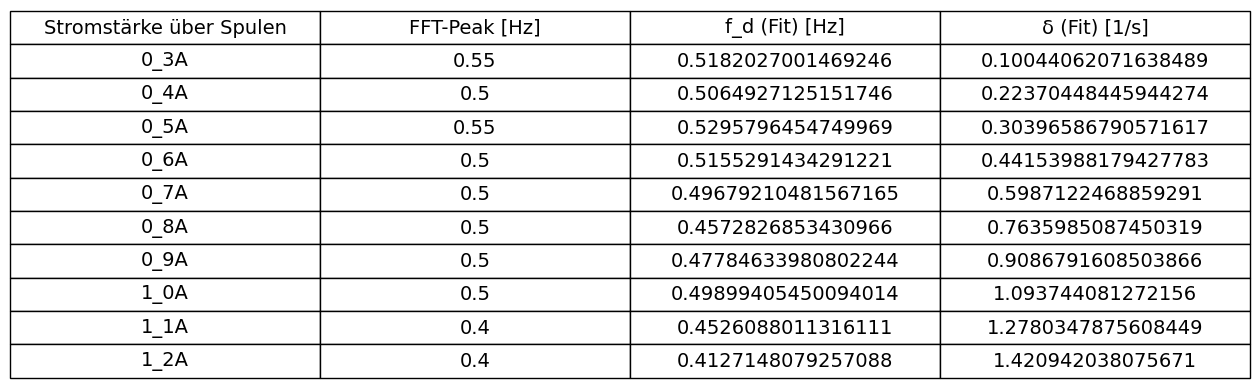

In [7]:
# | label: fig-tab-plot-fft
# | fig-cap: Tabelle der bestimmten Dämpfungskonstanten für die verschiedene Messungen

# ------------------------
# Ausgabe der Ergebnisse
# ------------------------
fig_table, axes_table = plt.subplots()
# hide axes
fig_table.patch.set_visible(False)
axes_table.axis('off')
axes_table.axis('tight')

# Ergebnisse in DataFrame umwandeln
res_df = pd.DataFrame(results)
#print("\nErgebnisse zusammengefasst:")
#print(res_df.to_string(index=False))

# Tabelle mit größerer Schrift und größerem Zellenabstand für bessere Lesbarkeit
table = axes_table.table(
    cellText=res_df.values,
    colLabels=res_df.columns,
    loc='center',
    cellLoc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(14)
table.scale(2.5, 2)  # (width, height) Skalierung der Tabelle

# ------------------------
# Layout & Show
# ------------------------
plt.show()

## $\omega_d$ als Funktion von $\delta$

Um die Funktion zu plotten muss bei dieser Aufgaben $\omega_d$ berechnet werden. Dies berechnet sich wie folgt.
$$\omega_d = \sqrt{\omega_0^2 - \delta^2}$$
FÜr den theoretischen Wert wird als $\omega_d$ der Median der gemessenen gedämpften Eigenfrequenzen. Weshalb wie in [Abbildung @fig-omega-over-delta] einige Werte sehr nah bei dem theoretsichen Wert liegen währen andere weiter weg liegen. Aber man kann trotzdem ganz gut sehen dass die gemessenen Werte der theoretischen Kurve folgen. Das sieht man besonders gut bei den Werten die in der nähe von der theoretischen Kurve liegen.

In [ ]:
# | label: fig-omega-over-delta
# | fig-cap: Plot von Omega über Delta
import numpy as np
import matplotlib.pyplot as plt

import matplotlib as mpl
mpl.rcParams['text.usetex'] = True
# Aus res_df bzw. results die Fit‑Parameter einlesen
# Annahme: du hast ein DataFrame `res_df` mit Spalten
# "δ (Fit) [1/s]" und "f_d (Fit) [Hz]" und dazu idealerweise
# Hier ein Minimal‑Beispiel:
delta = res_df["δ (Fit) [1/s]"].values
f_d   = res_df["f_d (Fit) [Hz]"].values
# Umrechnen in ω_d
omega_d = 2*np.pi * f_d

# Quadrate
delta2   = delta**2
omega2   = omega_d**2

# Lineare Regression (ω_d^2 gegen δ^2)
# ergibt slope ≈ -1/4 und intercept = ω0^2
coeffs = np.polyfit(delta2, omega2, 1)
slope, intercept = coeffs

# Theorielinie
delta2_lin = np.linspace(delta2.min(), delta2.max(), 100)
omega2_theory = intercept - 0.25 * delta2_lin

# Plot
plt.figure(figsize=(6,5))
plt.scatter(delta2, omega2, label="Daten (Fit‑Ergebnisse)")
plt.plot(delta2_lin, omega2_theory, '--',
         label=r"Theorie: $\omega_d^2 = \omega_0^2 - \tfrac14\,\delta^2$")
plt.plot(delta2_lin, slope*delta2_lin + intercept, ':',
         label=f"Lineare Regression\n(slope={slope:.3f}, int={intercept:.3f})")

plt.xlabel(r"$\delta^2\ (\mathrm{1/s}^2)$")
plt.ylabel(r"$\omega_d^2\ (\mathrm{1/s}^2)$")
plt.legend()
plt.grid(True)
#plt.tight_layout()
plt.show()


C:\Users\vd01p\AppData\Local\Temp\ipykernel_17216\264548224.py:8: MatplotlibDeprecationWarning: Support for setting an rcParam that expects a str value to a non-str value is deprecated since 3.5 and support will be removed two minor releases later.
  mpl.rcParams['text.latex.preamble'] = [r'\usepackage{amsmath}'] #for \text command


RuntimeError: Failed to process string with tex because latex could not be found

<Figure size 600x500 with 1 Axes>